# What we have, and how it fits together

Four artifacts came out of the bootstrap batch. This notebook opens each one,
shows a real example, and then walks a **single event** all the way from its row
in `events` to the actual newspaper articles about it.

Nothing here computes a result. It is a guided tour of the inputs.

Run it top to bottom: `.venv/bin/jupyter lab notebooks/01_explore_the_data.ipynb`

In [1]:
from pathlib import Path
import json, itertools
import pandas as pd
import matplotlib.pyplot as plt

from mediapos import config as cfg, queries as q

pd.set_option("display.max_colwidth", 46)
pd.set_option("display.width", 180)

events   = pd.read_csv(cfg.DATA_OUT / "events.csv")
entities = pd.read_csv(cfg.DATA_OUT / "entities.csv")
queries  = pd.read_csv(cfg.DATA_OUT / "queries.csv")
receipts = json.loads((cfg.DATA_OUT / "pull_receipts.json").read_text())

# Validated categorical slots (blue, orange, aqua) + recessive ink.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#dcdcd8"
plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlesize": 10,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
})
print("loaded.")

loaded.


## 1. The four artifacts

Three tables are versioned in git. The fourth — the articles themselves — is a
**cache**: 1.9 GB of licensed text that must never enter the repository. What is
versioned for it is the *receipt*, which carries enough to re-request the same
data and prove you got the same bytes.

In [2]:
n_articles = sum(r["articles_read"] for r in receipts.values())
n_bytes    = sum(r["compressed_bytes"] for r in receipts.values())

pd.DataFrame([
    {"artifact": "events", "rows": len(events),
     "one row is": "an event", "in git": "yes"},
    {"artifact": "entities", "rows": len(entities),
     "one row is": "an (event, actor, language)", "in git": "yes"},
    {"artifact": "queries", "rows": len(queries),
     "one row is": "a Swissdox query", "in git": "yes"},
    {"artifact": "corpus (receipts)", "rows": len(receipts),
     "one row is": "a downloaded window", "in git": "receipt only"},
    {"artifact": "corpus (articles)", "rows": n_articles,
     "one row is": "a newspaper article",
     "in git": f"NO -- {n_bytes / 1e9:.2f} GB cache"},
]).set_index("artifact")

,rows,one row is,in git
artifact,,,
events,20,an event,yes
entities,304,"an (event, actor, language)",yes
queries,20,a Swissdox query,yes
corpus (receipts),19,a downloaded window,receipt only
corpus (articles),1650143,a newspaper article,NO -- 1.93 GB cache


## 2. `events` — the 20 anchors

One row per event. The `block` column says what job that event does in the
design:

| block | what it is | why it exists |
|---|---|---|
| **A** | 8 federal popular votes | the graded signal — both axes are measured for these |
| **B** | 4 Federal Council elections | small, fully known cast: linking errors are *visible* |
| **C** | 3 Swiss events off the institutional calendar | does the method survive an unscheduled event? |
| **D** | 1 consensual vote | the **negative control** — expect no separation |
| **E** | 4 international events | `is_diagnostic` — tests the language confounder, **never calibrates** |

In [3]:
events[["event_id", "block", "date", "label_de", "label_fr", "n_reference_actors"]] \
    .sort_values(["block", "date"]).reset_index(drop=True)

,event_id,block,date,label_de,label_fr,n_reference_actors
0,A-628,A,2019-05-19,Umsetzung der EU-Waffenrichtlinie,Mise en oeuvre de la directive de l’UE sur...,12
1,A-631,A,2020-09-27,Begrenzungsinitiative,Initiative de limitation,12
2,A-636,A,2020-11-29,Konzernverantwortungsinitiative,Initiative «Entreprises responsables»,12
3,A-641,A,2021-06-13,Trinkwasserinitiative,Initiative pour une eau potable propre,11
4,A-644,A,2021-06-13,CO2-Gesetz,Loi sur le CO2,12
5,A-650,A,2021-11-28,Änderung des Covid-19-Gesetzes (2. Revision),Modification de la loi COVID-19 (2e révision),9
6,A-659,A,2022-09-25,Erhöhung der Mehrwertsteuer zugunsten der AHV,Relèvement de la TVA pour un financement a...,11
7,A-665,A,2024-03-03,Initiative für eine 13. AHV-Rente,Initiative pour une 13e rente AVS,11
8,B-Q57624299,B,2018-12-05,Bundesratswahl 2018,élection du Conseil fédéral suisse 2018,9
9,B-Q59550563,B,2019-12-11,Bundesratswahl 2019,élections du Conseil fédéral suisse de 2019,7


### The two axes, and why block A sits on a grid

Block A was not hand-picked. Two numbers were **computed** from the Swissvotes
file, and the 8 events are 2 per cell of the grid they define:

- **polarization** — how split the parties were, weighted by electorate.
  `0` = everyone agreed, `1` = evenly divided.
- **Röstigraben** — yes-share in French-speaking cantons *minus* German-speaking
  cantons. Positive = the French side liked it more.

The dashed lines are the medians of the 56-object candidate pool. They are the
cell boundaries, and they come from the data, not from a threshold anyone chose.

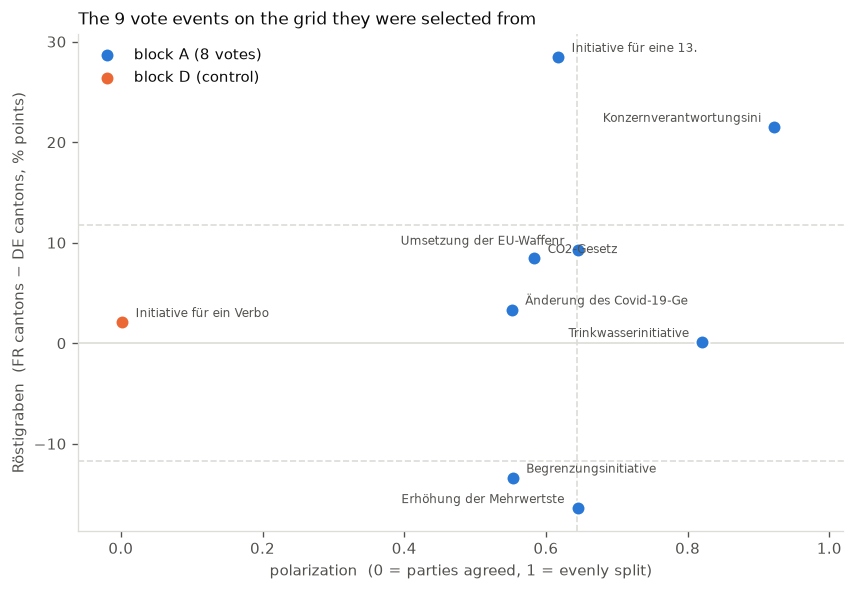

In [4]:
rule = json.loads((cfg.DATA_OUT / "manifest.json").read_text())["notes"]["selection_rule"]
med_pol = rule["block_A"]["median_polarization"]
med_gap = rule["block_A"]["median_abs_roestigraben"]

votes = events[events["polarization"].notna()]
fig, ax = plt.subplots(figsize=(7.2, 5))

for blk, color, name in [("A", BLUE, "block A (8 votes)"),
                         ("D", ORANGE, "block D (control)")]:
    sub = votes[votes["block"] == blk]
    ax.scatter(sub["polarization"], sub["roestigraben"], s=70, color=color,
               label=name, zorder=3, edgecolor="white", linewidth=1.2)

ax.axvline(med_pol, ls="--", lw=1, color=GRID, zorder=1)
for y in (med_gap, -med_gap):
    ax.axhline(y, ls="--", lw=1, color=GRID, zorder=1)
ax.axhline(0, lw=1, color=GRID, zorder=1)

# Place each label on the side with room, so none runs off the axes.
for _, r in votes.iterrows():
    right = r["polarization"] > 0.62
    ax.annotate(r["label_de"][:24], (r["polarization"], r["roestigraben"]),
                textcoords="offset points", xytext=(-8 if right else 8, 3),
                ha="right" if right else "left", fontsize=7, color=MUTED)
ax.set_xlim(-0.06, 1.02)

ax.set_xlabel("polarization  (0 = parties agreed, 1 = evenly split)")
ax.set_ylabel("Röstigraben  (FR cantons − DE cantons, % points)")
ax.set_title("The 9 vote events on the grid they were selected from", loc="left")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout(); plt.show()

Read it: the **orange point sits at polarization ≈ 0** — every party on the same
side, and almost no language gap. That is the control doing its job. If our
method later says outlets are far apart on *that* object, the method is measuring
noise.

## 3. `entities` — the actors, in long format

This is deliberately **one row per (event, actor, language)**, not a wide table.
An actor that appears in German and French gets two rows with the same `qid`.

That shape matters: add an `outlet` column and this *is* the edge list of the
bipartite graph the project is built on.

In [5]:
entities.head(6)

,event_id,qid,label,role,lang,surface_form,source,source_key,match_status
0,A-628,Q121882,Ida Glanzmann-Hunkeler,rapporteur,de,Ida Glanzmann-Hunkeler,curia:Rapporteur,PersonNumber:1337,matched
1,A-628,Q121882,Ida Glanzmann-Hunkeler,rapporteur,fr,Ida Glanzmann-Hunkeler,curia:Rapporteur,PersonNumber:1337,matched
2,A-628,Q16739430,Pierre-Alain Fridez,rapporteur,de,Pierre-Alain Fridez,curia:Rapporteur,PersonNumber:4074,matched
3,A-628,Q16739430,Pierre-Alain Fridez,rapporteur,fr,Pierre-Alain Fridez,curia:Rapporteur,PersonNumber:4074,matched
4,A-628,Q1310215,Josef Dittli,rapporteur,de,Josef Dittli,curia:Rapporteur,PersonNumber:4151,matched
5,A-628,Q1310215,Josef Dittli,rapporteur,fr,Josef Dittli,curia:Rapporteur,PersonNumber:4151,matched


### Every actor arrived through a key, never through a string

`source` says how each actor was found. None of these matched text — that is on
purpose, because this file is the **answer key** and an answer key built by fuzzy
matching would be worthless.

In [6]:
(entities.groupby(["source", "role"]).size()
         .rename("rows").reset_index()
         .assign(how=lambda d: d["source"].map({
             "swissvotes:party_recommendation": "party short name + life dates",
             "curia:Rapporteur":                "PersonNumber → Wikidata P1307",
             "wikidata:P39":                    "office held, date-filtered",
             "wikidata:event_actor":            "item→item link inside Wikidata",
         })))

,source,role,rows,how
0,curia:Rapporteur,rapporteur,52,PersonNumber → Wikidata P1307
1,swissvotes:party_recommendation,recommends_no,72,party short name + life dates
2,swissvotes:party_recommendation,recommends_yes,78,party short name + life dates
3,wikidata:P39,federal_councillor,66,"office held, date-filtered"
4,wikidata:event_actor,candidate,28,item→item link inside Wikidata
5,wikidata:event_actor,participant,8,item→item link inside Wikidata


### One event's cast

In [7]:
one = "A-631"   # Begrenzungsinitiative, 27 Sep 2020
cast = entities[(entities.event_id == one) & (entities.lang == "de")]
cast[["qid", "label", "role", "source_key"]].reset_index(drop=True)

,qid,label,role,source_key
0,Q121470,Kurt Fluri,rapporteur,PersonNumber:1122
1,Q1160790,Daniel Fässler,rapporteur,PersonNumber:4056
2,Q18413490,Valérie Piller Carrard,rapporteur,PersonNumber:4109
3,Q151768,Bürgerlich-Demokratische Partei,recommends_no,p-bdp
4,Q659461,Christlichdemokratische Volkspartei,recommends_no,p-cvp
5,Q667836,Eidgenössisch-Demokratische Union,recommends_yes,p-edu
6,Q667718,Evangelische Volkspartei,recommends_no,p-evp
7,Q202638,FDP.Die Liberalen,recommends_no,p-fdp
8,Q545900,Grünliberale Partei,recommends_no,p-glp
9,Q659739,Grüne Partei der Schweiz,recommends_no,p-gps


### The `qid` column is what makes this a network

65 distinct actors across 20 events. **20 of them appear in more than one event** —
and that shared identity is the only reason we get a connected graph instead of
20 unrelated islands.

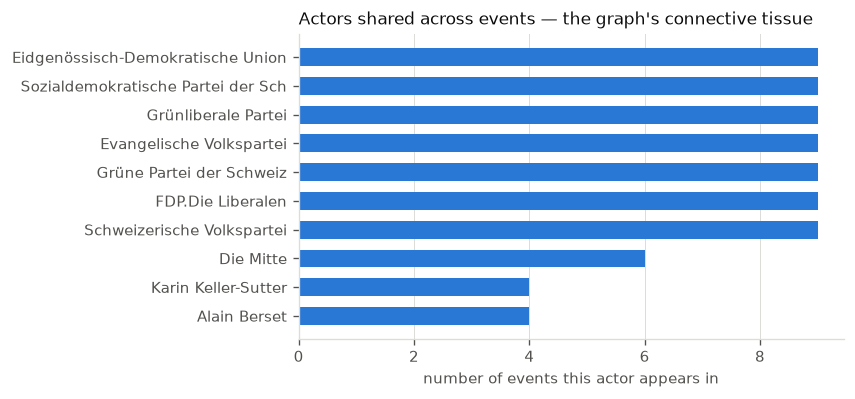

In [8]:
shared = (entities[entities.lang == "de"]
          .groupby(["qid"])["event_id"].nunique()
          .sort_values(ascending=False))
labels = entities.drop_duplicates("qid").set_index("qid")["label"]

top = shared[shared > 1].head(10)
fig, ax = plt.subplots(figsize=(7.2, 3.4))
ax.barh([labels.get(q, q)[:34] for q in top.index][::-1], top.values[::-1],
        color=BLUE, height=0.62)
ax.set_xlabel("number of events this actor appears in")
ax.set_title("Actors shared across events — the graph's connective tissue", loc="left")
ax.grid(axis="x", color=GRID, lw=0.6); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 4. The corpus — what was actually downloaded

19 windows, not 20: two ballot objects were voted **on the same day**, so they
share one window and one archive. Counting them twice would present the same
articles as two independent observations.

In [9]:
rec = (pd.DataFrame([
    {"window": k,
     "events": ", ".join(r["event_ids"]),
     "articles": r["articles_read"],
     "MB": round(r["compressed_bytes"] / 1e6),
     "de": r["by_language"].get("de", 0),
     "fr": r["by_language"].get("fr", 0)}
    for k, r in sorted(receipts.items())]))
rec

,window,events,articles,MB,de,fr
0,2018-07-05_2018-08-18,C-Q55972779,89003,93,62030,26973
1,2018-11-05_2018-12-19,B-Q57624299,97757,102,67633,30124
2,2019-04-19_2019-06-02,A-628,91450,87,62308,29142
3,2019-05-15_2019-06-28,C-Q64605546,94691,89,64363,30328
4,2019-11-11_2019-12-25,B-Q59550563,92708,89,62261,30447
5,2020-01-01_2020-02-14,E-Q7888194,89788,87,60287,29501
6,2020-08-28_2020-10-11,A-631,87403,97,58649,28754
7,2020-10-04_2020-11-17,E-Q22923830,84145,101,57215,26930
8,2020-10-30_2020-12-13,A-636,85108,103,58035,27073
9,2021-05-14_2021-06-27,"A-641, A-644",89587,105,62772,26815


### What one article looks like

The archives are compressed TSV. We never decompress them — rows are streamed
straight out of the `.xz`.

In [10]:
window = receipts[queries.set_index("event_id").loc[one, "date_from"]
                  + "_" + queries.set_index("event_id").loc[one, "date_to"]]
path = cfg.REPO_ROOT / window["local_path"]

article = next(q.read_articles(path))
for field in ("id", "pubtime", "medium_code", "medium_name", "language", "head"):
    print(f"{field:<12} {article[field]}")
print(f"{'content':<12} {article['content'][:180]}…")

id           40619584
pubtime      2020-09-16 09:31:06+02
medium_code  ZWAO
medium_name  20 minuten online
language     de
head         «So etwas erleben wir vielleicht einmal in 10 bis 20 Jahren»
content      <tx><ld><p>Dem baldigen Herbstbeginn zum Trotz übertrafen an mehreren Orten in der Schweiz die Temperaturen in den letzten zwei Tagen die 30-Grad-Marke. Eine Hitzewelle ist das jed…


**Note what that first article is about.** Almost certainly not the vote.

The pull is deliberately **unfiltered** — everything the 34 outlets published in
the window. On this window only **1.7 %** of articles mention the ballot object.
The other 98 % are not noise, they are the **denominator**: visibility is a
*share* of attention, and a share without a denominator is just a count.

## 5. How it all connects

```
  events ──event_id──┬── entities   (N per event: its actors, 2 rows per language)
                     │
                     └── queries ──window──► corpus archive (.tsv.xz)
                                                    │
   entities.qid ─────────── mentioned in ───────────┘
        │
        └──► the bipartite edge we are actually after:
             (outlet, actor)  weighted by how often that outlet names that actor
```

Three keys, three different jobs:

| key | joins | what it gives you |
|---|---|---|
| `event_id` | events ↔ entities ↔ queries | everything about one event |
| `qid` | entities ↔ entities | the same actor across events — makes it a *graph* |
| window | queries ↔ archive | the articles for that event |

Let's walk it for one event.

In [11]:
row   = events.set_index("event_id").loc[one]
qrow  = queries.set_index("event_id").loc[one]
cast_ = entities[entities.event_id == one]

print(f"EVENT    {one}  {row['date']}  {row['label_de']}")
print(f"         block {row['block']}, polarization {row['polarization']:.2f}, "
      f"Röstigraben {row['roestigraben']:+.1f}")
print(f"ACTORS   {cast_['qid'].nunique()} distinct, {len(cast_)} rows (2 per language)")
print(f"WINDOW   {qrow['date_from']} → {qrow['date_to']}, {qrow['n_sources']} outlets")
print(f"ARTICLES {window['articles_read']:,} in that window")

EVENT    A-631  2020-09-27  Begrenzungsinitiative
         block A, polarization 0.55, Röstigraben -13.4
ACTORS   12 distinct, 24 rows (2 per language)
WINDOW   2020-08-28 → 2020-10-11, 34 outlets
ARTICLES 87,403 in that window


### From text to edges

Now the actual connection. We scan articles for the reference actors' names and
count, per outlet, how often each actor is named.

**This is a deliberately naive regex scan** — a demonstration of the *shape*, not
the real linker. Party abbreviations like `SP` or `PS` match all sorts of things,
so these counts are an **upper bound**. Building a linker that does this properly
is the core of the project; this cell shows why it is needed.

Capped at 30,000 articles to keep the notebook fast.

In [12]:
import re

# Surface forms per party, and the de/fr short label to show on charts.
SHORT = {"Q385258": ["SVP", "UDC"], "Q303745": ["SP", "PS"],
         "Q202638": ["FDP", "PLR"], "Q659461": ["CVP", "PDC"],
         "Q659739": ["Grüne", "Verts"], "Q545900": ["GLP", "PVL"]}
SHORT_LABEL = {q_: "/".join(v) for q_, v in SHORT.items()}
names = {q_: re.compile(r"\b(" + "|".join(v) + r")\b") for q_, v in SHORT.items()}

counts, totals, outlet_lang = {}, {}, {}
for art in itertools.islice(q.read_articles(path), 30_000):
    med, text = art["medium_code"], art["content"] or ""
    totals[med] = totals.get(med, 0) + 1
    outlet_lang[med] = art["language"]
    for qid_, pat in names.items():
        if pat.search(text):
            counts[(med, qid_)] = counts.get((med, qid_), 0) + 1

edges = (pd.Series(counts).rename("mentions").reset_index()
           .rename(columns={"level_0": "outlet", "level_1": "qid"}))
edges["published"] = edges["outlet"].map(totals)
edges["share_%"]   = (100 * edges["mentions"] / edges["published"]).round(2)
edges["actor"]     = edges["qid"].map(SHORT_LABEL)
print(f"{len(edges)} (outlet, actor) edges from {sum(totals.values()):,} articles")
edges.sort_values("share_%", ascending=False).head(8).reset_index(drop=True)

198 (outlet, actor) edges from 30,000 articles


,outlet,qid,mentions,published,share_%,actor
0,SGTO,Q202638,267,1552,17.20,FDP/PLR
1,SGTO,Q385258,252,1552,16.24,SVP/UDC
2,SGTO,Q303745,252,1552,16.24,SP/PS
3,SGTO,Q659461,227,1552,14.63,CVP/PDC
4,WOZ,Q303745,10,72,13.89,SP/PS
5,WEW,Q303745,15,139,10.79,SP/PS
6,WEW,Q385258,15,139,10.79,SVP/UDC
7,AZM,Q385258,161,1587,10.14,SVP/UDC


`share_%` is the number that matters, not `mentions`. "*Le Temps* named the UDC
in 4.1 % of everything it published" is comparable across outlets; "named it 200
times" is not — a bigger newsroom always wins.

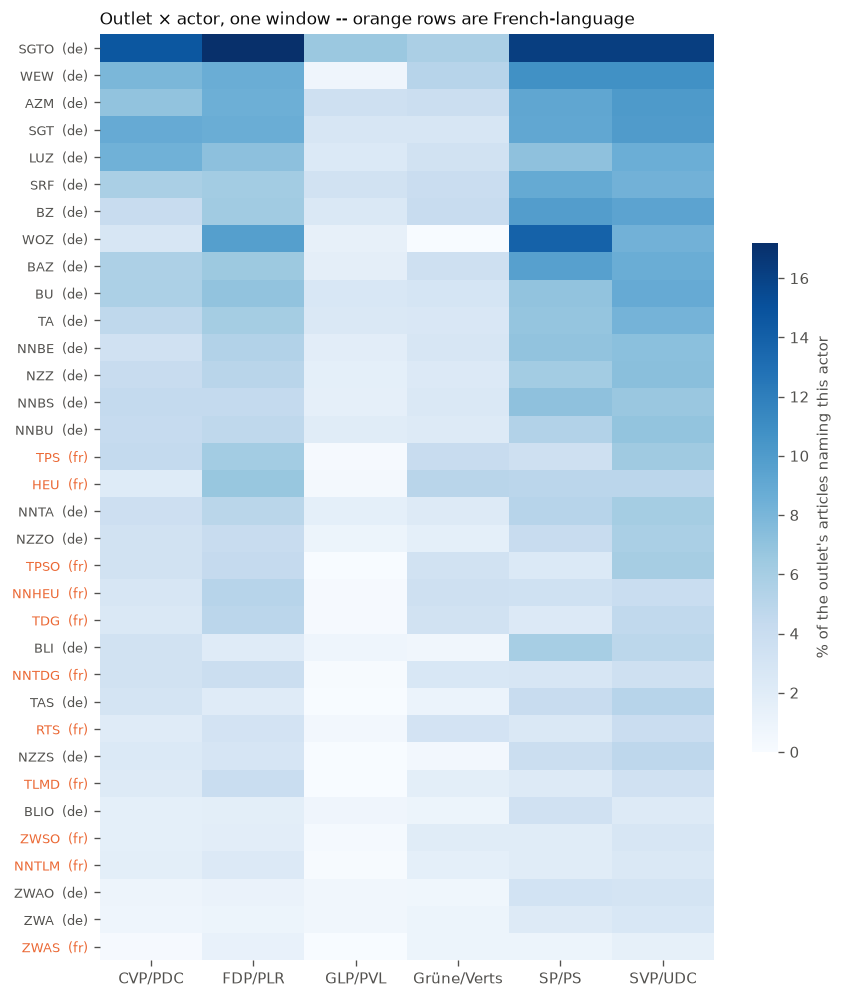

In [13]:
# Every outlet, not a top-N: cutting the list would hide the pattern below.
piv = (edges.pivot_table(index="outlet", columns="actor", values="share_%")
            .fillna(0))
piv = piv.loc[piv.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(7.4, 8.4))
im = ax.imshow(piv.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(piv.columns)))
ax.set_xticklabels(list(piv.columns), rotation=0, ha="center")
ax.set_yticks(range(len(piv.index)))
ax.set_yticklabels([f"{m}  ({outlet_lang[m]})" for m in piv.index], fontsize=8)
# Language is spelled out in the tick, never carried by colour alone.
for tick, m in zip(ax.get_yticklabels(), piv.index):
    tick.set_color(ORANGE if outlet_lang[m] == "fr" else MUTED)
for spine in ax.spines.values():
    spine.set_visible(False)
cb = fig.colorbar(im, ax=ax, shrink=0.55)
cb.set_label("% of the outlet's articles naming this actor", color=MUTED)
cb.outline.set_visible(False)
ax.set_title("Outlet × actor, one window -- orange rows are French-language",
             loc="left", fontsize=10)
plt.tight_layout(); plt.show()

That heatmap is the project in miniature. Every non-empty cell is an edge; the
value is the weight. Do this over sliding windows instead of one, and the
outlet's position becomes a trajectory.

### And look at the row order

**The top 16 outlets are all German-language. The first French one lands 17th.**

That is the whole problem of this project, appearing on the very first chart.
Either German-Swiss papers really do write about federal parties in a larger
share of their articles, **or** our German surface forms match better than our
French ones — `SVP` is used relentlessly in German copy, while French text may
prefer *"le Parti socialiste"* over `PS`.

We cannot tell which from this chart, and that is exactly why block **E** exists:
international events where the actors are *identical* on both sides of the
Röstigraben. If the gap survives there, it is measurement, not politics.

Do not read this heatmap as a finding. Read it as the question.

## What this notebook does **not** show

- **Deduplication.** *Tages-Anzeiger* and *Der Bund* run identical articles on
  the same day — same owner, shared newsroom. Counting both inflates apparent
  agreement. Near-duplicate detection comes before any co-positioning claim.
- **Real entity linking.** The scan above is regex. `SP` matches far more than
  the Social Democrats.
- **Tone.** Visibility is *who* gets named. Whether they are named favourably is
  a separate question.
- **Block E.** The international events are `is_diagnostic` and must be excluded
  from any calibration — they exist only to test whether the dominant axis is
  measuring language rather than ideology.